# Comparison of Model 1 and Model 2
**CAP182 Capstone Project: STADIOEquities**

Compares Model 1 (Logistic Regression) and Model 2 (Decision Tree) on the same unseen test period, using side-by-side metrics with confidence intervals, a paired bootstrap test of the differences, McNemar's test, a paired comparison of cross-validation folds, overlaid curves and the robustness check.

Requires both saved models and `data/train.csv` / `data/test.csv`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             classification_report, roc_auc_score)
from sklearn.calibration import calibration_curve

sys.path.append("..")
from utils.evaluation_utils import (bootstrap_metrics, gains_table, threshold_table,
                                    paired_bootstrap_difference, compute_metrics)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
X_train, y_train = train.drop(columns="y"), train["y"]
X_test, y_test = test.drop(columns="y"), test["y"]
from scipy.stats import binomtest, ttest_rel

models = {
    "Model 1: Logistic Regression": joblib.load("../models/model1_logistic_regression.pkl"),
    "Model 2: Decision Tree": joblib.load("../models/model2_decision_tree.pkl"),
}
probs = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}
names = list(models)

## 1. Side-by-side metrics with 95% bootstrap confidence intervals

In [2]:
tables = {name: bootstrap_metrics(y_test, p, n_boot=1000, seed=RANDOM_SEED) for name, p in probs.items()}
side_by_side = pd.concat({name: t.apply(lambda r: f"{r['Value']:.3f} ({r['95% CI lower']:.3f} to {r['95% CI upper']:.3f})", axis=1)
                          for name, t in tables.items()}, axis=1)
side_by_side.to_csv("comparison_metrics.csv")
side_by_side

,Model 1: Logistic Regression,Model 2: Decision Tree
Accuracy,0.450 (0.439 to 0.460),0.420 (0.410 to 0.431)
Balanced accuracy,0.584 (0.576 to 0.591),0.496 (0.486 to 0.506)
Precision,0.352 (0.340 to 0.363),0.306 (0.293 to 0.318)
Recall (sensitivity),0.932 (0.922 to 0.941),0.693 (0.676 to 0.711)
Specificity,0.236 (0.224 to 0.246),0.299 (0.287 to 0.310)
F1-Score,0.511 (0.498 to 0.523),0.424 (0.411 to 0.438)
ROC AUC,0.741 (0.728 to 0.752),0.552 (0.539 to 0.567)
PR AUC (average precision),0.539 (0.518 to 0.560),0.389 (0.372 to 0.406)
Brier score,0.315 (0.310 to 0.320),0.266 (0.261 to 0.269)


## 2. Paired bootstrap test of the differences (Model 1 minus Model 2)
Both models are evaluated on the **same** 1,000 resamples of the test set, so the difference is measured fairly. If the 95% confidence interval for a difference excludes 0, the difference is statistically significant at the 5% level. The Brier score is an error measure, so a negative difference favours Model 1.

In [3]:
diff = paired_bootstrap_difference(y_test, probs[names[0]], probs[names[1]], n_boot=1000, seed=RANDOM_SEED)
diff.to_csv("comparison_differences.csv")
diff

,Difference (A - B),95% CI lower,95% CI upper,Bootstrap p-value
Accuracy,0.030,0.019,0.040,<0.001
Balanced accuracy,0.088,0.077,0.098,<0.001
Precision,0.046,0.040,0.052,<0.001
Recall (sensitivity),0.239,0.221,0.256,<0.001
Specificity,-0.063,-0.075,-0.050,<0.001
F1-Score,0.087,0.077,0.096,<0.001
ROC AUC,0.188,0.173,0.202,<0.001
PR AUC (average precision),0.150,0.135,0.165,<0.001
Brier score,0.049,0.044,0.055,<0.001


## 3. McNemar's test on the yes/no predictions
McNemar's test looks only at customers where the two models disagree: those Model 1 classified correctly but Model 2 did not, and vice versa. Under the null hypothesis of equal error rates, these two counts should be similar. An exact binomial version of the test is used.

In [4]:
correct1 = (probs[names[0]] >= 0.5).astype(int) == y_test.values
correct2 = (probs[names[1]] >= 0.5).astype(int) == y_test.values
b = int((correct1 & ~correct2).sum())   # Model 1 right, Model 2 wrong
c = int((~correct1 & correct2).sum())   # Model 1 wrong, Model 2 right
p_mcnemar = binomtest(b, b + c, 0.5).pvalue
pd.Series({"Model 1 right, Model 2 wrong": b, "Model 1 wrong, Model 2 right": c,
           "McNemar exact p-value": f"{p_mcnemar:.2e}"})

Model 1 right, Model 2 wrong        1108
Model 1 wrong, Model 2 right         859
McNemar exact p-value           2.16e-08
dtype: object

## 4. Paired comparison of cross-validation folds (training period)
Both models are scored on identical 5-fold splits of the training period, and a paired t-test compares the fold AUCs. With only 5 folds that share training data, this test is indicative rather than definitive.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = pd.DataFrame({name: cross_val_score(clone(m), X_train, y_train, cv=cv, scoring="roc_auc")
                          for name, m in models.items()}, index=[f"Fold {i}" for i in range(1, 6)])
t_stat, p_cv = ttest_rel(cv_scores[names[0]], cv_scores[names[1]])
print(cv_scores.round(3))
print("\nMean ± SD:")
for n in names:
    print(f"  {n}: {cv_scores[n].mean():.3f} ± {cv_scores[n].std(ddof=1):.3f}")
print(f"Paired t-test: t = {t_stat:.2f}, p = {p_cv:.3f}")

        Model 1: Logistic Regression  Model 2: Decision Tree
Fold 1                         0.670                   0.665
Fold 2                         0.671                   0.659
Fold 3                         0.669                   0.670
Fold 4                         0.692                   0.663
Fold 5                         0.655                   0.666

Mean ± SD:
  Model 1: Logistic Regression: 0.671 ± 0.013
  Model 2: Decision Tree: 0.665 ± 0.004
Paired t-test: t = 1.00, p = 0.373


## 5. Overlaid ROC curves and cumulative gains

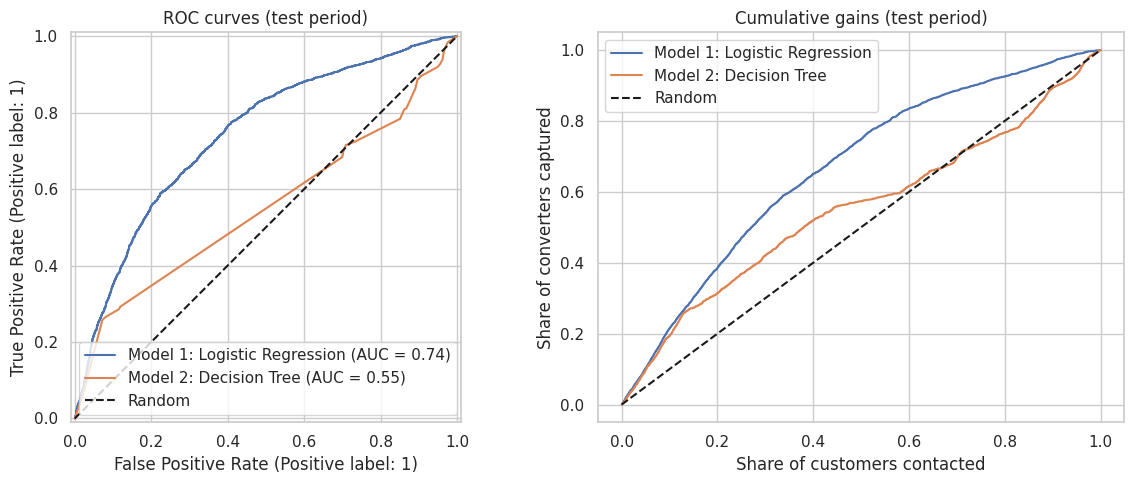

,Model 1: Logistic Regression,Model 2: Decision Tree
Top share contacted,,
10%,0.215,0.193
20%,0.385,0.314
30%,0.540,0.421
50%,0.748,0.573


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, p in probs.items():
    RocCurveDisplay.from_predictions(y_test, p, name=name, ax=axes[0])
    order = np.argsort(-p)
    gains = np.cumsum(y_test.values[order]) / y_test.sum()
    axes[1].plot(np.arange(1, len(gains) + 1) / len(gains), gains, label=name)
for ax in axes:
    ax.plot([0, 1], [0, 1], "k--", label="Random")
    ax.legend()
axes[0].set_title("ROC curves (test period)")
axes[1].set_title("Cumulative gains (test period)")
axes[1].set_xlabel("Share of customers contacted"); axes[1].set_ylabel("Share of converters captured")
plt.tight_layout(); plt.savefig("figures/comparison_curves.png", dpi=150); plt.show()

pd.concat({n: gains_table(y_test, p)["Converters captured"] for n, p in probs.items()}, axis=1)

## 6. Robustness: time-ordered vs random split

In [7]:
X_all, y_all = pd.concat([X_train, X_test]), pd.concat([y_train, y_test])
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all,
                                              random_state=RANDOM_SEED)
robust = pd.DataFrame({
    "ROC AUC, time-ordered split": {n: roc_auc_score(y_test, probs[n]) for n in names},
    "ROC AUC, random split": {n: roc_auc_score(yr_te, clone(m).fit(Xr_tr, yr_tr).predict_proba(Xr_te)[:, 1])
                              for n, m in models.items()},
}).round(3)
robust["Drop"] = (robust.iloc[:, 1] - robust.iloc[:, 0]).round(3)
robust.to_csv("comparison_robustness.csv")
robust

,"ROC AUC, time-ordered split","ROC AUC, random split",Drop
Model 1: Logistic Regression,0.741,0.800,0.059
Model 2: Decision Tree,0.552,0.799,0.247
